# Linear Regression and the Open Asteroid Dataset
This dataset of over 800,000 known asteroids is collected from the Small Body Database maintained by the NASA's Jet Propulsion Laboratory (JPL). It contains information about each asteroid's orbit and known measurable properties. New entires are added daily and can be obtained through the NASA Open Data Portal: 
https://data.nasa.gov/dataset/jpl-small-body-database-browser 

or the JPL portal: 
https://ssd.jpl.nasa.gov/tools/sbdb_query.html

The dataset provided was obtained from Basu (2019) IJAECS, 6, 4, 2394-2835. (Feel free to use an up-to-date dataset instead!)

***The goal of this notebook is to train a linear regression model to predict the properties of asteroids given some subset of available observations.*** In particular, we will focus on estimating asteroid diameters, but other features may also be explored if desired.

In [9]:
# Importing the packages required for this exercise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import PolynomialFeatures 

## Data Inspection

Before you can begin building a ML model, you must first understand the data you are given and how they relate to the overarching objective of your model. Visualizing the data is always a good first step!

### Objective: 
*Start by reading in the data as a DataFrame and printing off some information, to get a feel for the type of data contained in this set. Make special note of the datatypes each entry is given as. Feel free to plot the data to help visualize them.*

In [2]:
# Reading in the data
asteroids = pd.read_csv("open_asteroid/Asteroid_Updated.csv") #input your file path

# Display the whole dataframe...
display(asteroids)

# ... or you can print a random sample to get a better feel for how much data is or is not available
asteroids.sample(10)

/var/folders/l5/_4m7d9_j7j95_8strxhsvct40000gn/T/ipykernel_14358/714500760.py:2: DtypeWarning: Columns (0,10,15,16,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  asteroids = pd.read_csv("open_asteroid/Asteroid_Updated.csv") #input your file path


,name,a,e,i,om,w,q,ad,per_y,data_arc,...,UB,IR,spec_B,spec_T,G,moid,class,n,per,ma
0,Ceres,2.769165,0.076009,10.594067,80.305532,73.597694,2.558684,2.979647,4.608202,8822.0,...,0.426,NaN,C,G,0.12,1.594780,MBA,0.213885,1683.145708,77.372096
1,Pallas,2.772466,0.230337,34.836234,173.080063,310.048857,2.133865,3.411067,4.616444,72318.0,...,0.284,NaN,B,B,0.11,1.233240,MBA,0.213503,1686.155999,59.699133
2,Juno,2.669150,0.256942,12.988919,169.852760,248.138626,1.983332,3.354967,4.360814,72684.0,...,0.433,NaN,Sk,S,0.32,1.034540,MBA,0.226019,1592.787285,34.925016
3,Vesta,2.361418,0.088721,7.141771,103.810804,150.728541,2.151909,2.570926,3.628837,24288.0,...,0.492,NaN,V,V,0.32,1.139480,MBA,0.271609,1325.432765,95.861936
4,Astraea,2.574249,0.191095,5.366988,141.576605,358.687607,2.082324,3.066174,4.130323,63507.0,...,0.411,NaN,S,S,NaN,1.095890,MBA,0.238632,1508.600458,282.366289
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839709,NaN,2.812945,0.664688,4.695700,183.310012,234.618352,0.943214,4.682676,4.717914,17298.0,...,NaN,NaN,NaN,NaN,NaN,0.032397,APO,0.208911,1723.217927,156.905910
839710,NaN,2.645238,0.259376,12.574937,1.620020,339.568072,1.959126,3.331350,4.302346,16.0,...,NaN,NaN,NaN,NaN,NaN,0.956145,MBA,0.229090,1571.431965,13.366251
839711,NaN,2.373137,0.202053,0.732484,176.499082,198.026527,1.893638,2.852636,3.655884,5.0,...,NaN,NaN,NaN,NaN,NaN,0.893896,MBA,0.269600,1335.311579,355.351127
839712,NaN,2.260404,0.258348,9.661947,204.512448,148.496988,1.676433,2.844376,3.398501,10.0,...,NaN,NaN,NaN,NaN,NaN,0.680220,MBA,0.290018,1241.302609,15.320134


,name,a,e,i,om,w,q,ad,per_y,data_arc,...,UB,IR,spec_B,spec_T,G,moid,class,n,per,ma
801182,NaN,2.360701,0.103694,8.065215,28.861885,332.723702,2.115911,2.605491,3.627185,3560.0,...,NaN,NaN,NaN,NaN,NaN,1.116610,MBA,0.271733,1324.829222,249.945781
353135,NaN,2.526789,0.209166,7.966677,200.177768,329.340802,1.998270,3.055308,4.016629,6324.0,...,NaN,NaN,NaN,NaN,NaN,1.008800,MBA,0.245386,1467.073761,208.346435
808013,NaN,2.787388,0.103528,3.000997,312.040726,69.931361,2.498814,3.075962,4.653764,10.0,...,NaN,NaN,NaN,NaN,NaN,1.502800,MBA,0.211791,1699.787435,220.505157
837800,NaN,2.288204,0.395393,26.560996,229.789792,133.063712,1.383463,3.192945,3.461388,154.0,...,NaN,NaN,NaN,NaN,NaN,0.469897,MCA,0.284749,1264.272078,317.512356
442713,NaN,2.296521,0.144679,3.687780,283.724753,15.918126,1.964263,2.628778,3.480276,4605.0,...,NaN,NaN,NaN,NaN,NaN,0.948124,MBA,0.283203,1271.170847,40.463821
4836,Bickerton,3.196559,0.137099,28.199928,327.114935,45.345395,2.758315,3.634802,5.715210,15030.0,...,NaN,NaN,NaN,NaN,NaN,1.803030,MBA,0.172457,2087.480588,6.909892
342188,NaN,2.602302,0.299540,6.494175,13.867218,340.184577,1.822807,3.381796,4.198022,4343.0,...,NaN,NaN,NaN,NaN,NaN,0.818962,MBA,0.234783,1533.327513,200.741140
770107,NaN,2.667059,0.319257,8.546279,196.084348,197.404360,1.815581,3.518536,4.355691,4.0,...,NaN,NaN,NaN,NaN,NaN,0.822859,MBA,0.226285,1590.916256,356.804096
704021,NaN,3.152495,0.104438,13.272285,68.940300,134.763486,2.823256,3.481735,5.597446,28.0,...,NaN,NaN,NaN,NaN,NaN,1.834970,MBA,0.176085,2044.467009,331.207850
813244,NaN,2.642820,0.124151,9.887529,208.090886,30.568921,2.314712,2.970928,4.296448,6724.0,...,NaN,NaN,NaN,NaN,NaN,1.309420,MBA,0.229405,1569.277683,126.011145


### Header descriptions

You should notice that the dataset contains 27 unique columns. Below is a brief description of what each header means. 
* **name**: *Object name/designation*
* **a**: *semi-major axis [AU]*
* **e**: *eccentricity*
* **G**: *magnitude slope parameter (helps predict the magnitude of brightness as a function of the solar phase angle)*
* **i**: *inclination with respect to the xy ecliptic plane*
* **om**: *longitude of the ascending node*
* **w**: *argument of perihelion*
* **q**: *perihelion distance [AU]*
* **ad**: *aphelion distance [AU]*
* **per_y**: *Orbital period (around the sun) [yrs]*
* **data-arc**: *data arc-span [d]*
* **condition_code**: *Orbit condition code (uncertainty in orbital parameters rated from 0-9, where 0 is well-known and 9 is poorly-constrained)*
* **n_obs_used**: *number of observations used*
* **H**: *absolute magnitude parameter (brightness it would have if observed 1 AU from Sun)*
* **diameter**: *asteroid diameter [km]*
* **extent**: *object bi/tri-axial ellipsoid dimensions [km]*
* **albedo**: *geometric albedo (reflectiveness on scale of 0-1, where 1 = perfect light reflection)*
* **rot_per**: *rotation period (around rotational axis) [hrs]*
* **GM**: *standard gravitational parameter (mass times gravitational constant)*
* **BV**: *color index Bmag-Vmag*
* **UB**: *color index Umag-Bmag*
* **IR**: *color index Imag-Rmag*
* **spec_B**: *spectral taxonomic type (SMASSII)*
* **spec_T**: *spectral taxonomic type (Tholen)*
* **neo**: *Near Earth Object flag (bool)*
* **pha**: *Physically Hazardous Asteroid flag (bool)*
* **moid**: *Earth Minimum Orbit Intersection Distance [AU]*

#### Orbital Parameters

The orbits of each asteroid around the sun are described in several ways within this dataset. 

The shape of an asteroid's orbit is described by the semi-major axis (a) and eccentricity (e). The eccentricity describes how circular (e = 0) or elliptical (0 < e < 1) the orbit is. The semi-major axis is its farthest distance from the center of the circle/ellipse. The semi-minor axis (closest distance from center) can be calculated as $b = a\sqrt{1-e^{2}}$, such that larger eccentricities lead to shorter semi-minor axes (could this be useful for our models?).

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/76/An_image_describing_the_semi-major_and_semi-minor_axis_of_ellipse.svg/960px-An_image_describing_the_semi-major_and_semi-minor_axis_of_ellipse.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20141026153810" width="500"/>


(Credit: Wikimedia Commons, Sae1962)

The distance between each asteroid and the sun is described through the perihelion and aphelion distances (the minimum and maximum distance along the semi-major axis of the object's orbit), as shown below: 

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c5/Perihelion_aphelion_semimajor_axis.svg/960px-Perihelion_aphelion_semimajor_axis.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20210920195140" width="500"/>

(Credit: Wikimedia Commons, Maxmath12) 

The inclination (i), longitude of the ascending node (om), and argument of perihelion (w) together give the three-dimensional tilt in the orbit of each object, as shown below:

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Orbit1.svg/960px-Orbit1.svg.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail&_=20230508033814" width="400"/>

(Credit: Wikipedia, Lasunncty) 

#### Brightness, Color, and Classifications

Asteroids and other small bodies may be classified in several ways based on parameters such as their brightness, reflectiveness, and colors. The SMASS and Tholen classifications are two such systems represented in this data set (**spec_B** and **spec_T**). The definition of each classification flag can be found here: https://en.wikipedia.org/wiki/Asteroid_spectral_types

The colors of objects are calculated by subtracting their absolute magnitudes measured within any 2 color filters. Represented in this dataset are  **BV** (blue vs. green), **UB** (ultra-violet vs. blue), and **IR** (infrared vs. red). Colors can be a useful means of measuring how objects interact (or emit) light, which may help determine what type of object it is. 

This example below shows a color-color diagram of small-body populations, including Kuiper belt objects (red), comets (cyan), and asteroids of different Tholen classifications (black and white circles, with classifications marked):

<img src="small-body_CCD.png" width="400"/>

(Credit: Filacchione et al. 2022)

The amount of light reflected by an asteroid is described by a combination of the absolute magnitude parameter (H) and the geometric albedo (albedo). The albedo of an object is the ratio of the actual brightness we observe and that of a perfectly reflecting object of the same size, largely dependent on the surface material of the asteroid. For example, Saturn and its moon Titan receive the same amount of sunlight, but because Titan has a lower albedo, it appears dimmer than Saturn: 

<img src="https://upload.wikimedia.org/wikipedia/commons/3/36/Titan_and_Saturn_-_May_6_2012_-_combined_%2835516187116%29.jpg" width="400"/>
(Credit: Kevin Gill) 


On the other hand, the absolute magnitude parameter (H) is the hypothetical brightness we would observe if the object was 1 AU from the Sun. The absolute magnitude parameter and albedo are intrinsically linked; the more reflective a given surface is, the brighter you would expect it to appear if for a given amount of sunlight.

## Feature Selection
In this notebook, we are building a model that can predict the diameter of a given asteroid using linear regression. Based on the information provided above and within the dataset, which properties (features) would you expect to be most strongly linked to asteroid diameter? Those are the features you should start with for your model. 

### Objective: 
*Decide which features to use in your model and add them to a list.*

*NOTE: Obviously, "diameter" cannot be among these headers, since we will be using it as our label! Do not use the "extent" header either, as this is a direct description of the object's shape and size. In the spirit of this exercise, only use properties that are not directly a measurement of size.*

In [3]:
# Set up masks (lists) to help select the features of interest
feat_list = ["albedo", "H", "BV", "UB"]
label = ["diameter"]

## Cleaning the Data

You will notice that not every asteroid in the dataset contains valid numbers for every feature, which can make the model difficult to create. In order to set up your training and test sets, you must first figure out how to handle of all of the "bad" data -- those that contain NaNs or no values. 

### Objective:
*Based on the features selected, determine what subset of the full dataset is appropriate. Remove any entry that contains NaNs (or handle them in some other way that does not disturb the ML process), and create a DataFrame containing only the data you will use in training/testing your model. Check your resulting dataset(s) to make sure it looks as expected.*

In [4]:
### EXAMPLE SOLUTION ###

# Pulling features from full DataFrame and building new frame with only values of interest
df_values = [asteroids[i].values for i in feat_list+label]
df_values = np.array(df_values).T

# Building new DataFrame
good_data = pd.DataFrame(columns=feat_list+label, data=df_values.tolist())

# Removing rows containing NaN
good_data = good_data.dropna(how="any").reset_index(drop=True)

# Pulling the good features and labels
good_feats = good_data.drop(label, axis=1)
good_labels= good_data.drop(columns=feat_list, axis=1)

display(good_feats), display(good_labels)

,albedo,H,BV,UB
0,0.0900,3.34,0.713,0.426
1,0.1010,4.13,0.635,0.284
2,0.2140,5.33,0.824,0.433
3,0.4228,3.20,0.782,0.492
4,0.2740,6.85,0.826,0.411
...,...,...,...,...
953,0.0500,15.99,0.666,0.279
954,0.1800,19.40,0.930,0.463
955,0.1500,15.10,0.677,0.267
956,0.0460,20.19,0.640,0.160


,diameter
0,939.4
1,545
2,246.596
3,525.4
4,106.699
...,...
953,4
954,0.6
955,2.3
956,0.492


(None, None)

## First-pass model

Now that you have a clean dataset containing only the information you will need to develop your model, it's time to build and train your linear regression model! To begin, we will first attempt to train a model using only the data provided within the (cleaned) dataset, without making any alterations to the data (later, we'll see how strategic data manipulation can help improve models). Then, we will test the newly-trained model to see how well it performs. 

### Objectives: 
- *Create and train a linear regression model based only on the features selected. Perform some statistical analyses to determine how well your model is performing based on the training set data.*

- *Test your model on the test set. How accurate are your estimated diameter values, compared to the actual asteroid diameters? Where does your model do well, and where does it fail?*

718 240

MODEL RESULTS
-------------
Intercept: [391.86514695]
Slopes: ['-45.87 (albedo)', '-20.7 (H)', '-194.486 (BV)', '96.474 (UB)']

OTHER STATS:
------------

Train MSE: 1863.9444210785753
Test  MSE: 1340.5877378351963
Train RMSE: 43.17342262409335
Test  RMSE: 36.61403744242359
Train R²: 0.5487653235514003
Test  R²: 0.6572588685181542

Testing model...
Results:


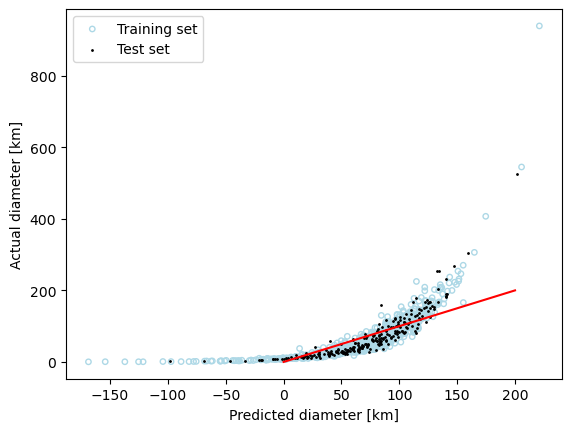

In [5]:
### EXAMPLE SOLUTIONS ###
# Building the training and test set
feat_train, feat_test, label_train, label_test = train_test_split(good_feats, good_labels, test_size=0.25, random_state=3)
print(len(feat_train), len(feat_test)) # check to make sure the split worked

# Creating the model
model = LinearRegression()
# Training the model
model.fit(feat_train, label_train)

# Print results!
print(f"\nMODEL RESULTS\n-------------\nIntercept: {model.intercept_}\nSlopes: {[f"{round(model.coef_[0][i],3)} ({feat_list[i]})" for i in range(len(feat_list))]}")
        
# Checking stats learned in workshops         
print(f"\nOTHER STATS:\n------------\n")
yhat_train = model.predict(feat_train)  # predict train
yhat_test  = model.predict(feat_test)  # predict test

mse_train = mean_squared_error(label_train, yhat_train)  # train error
mse_test  = mean_squared_error(label_test, yhat_test)  # test error

# Root Mean Squared Error
rmse_train = np.sqrt(mse_train)  # train rmse
rmse_test  = np.sqrt(mse_test)  # test rmse

print("Train MSE:", mse_train)  # print train mse
print("Test  MSE:", mse_test)  # print test mse

print("Train RMSE:", rmse_train)  # print train rmse
print("Test  RMSE:", rmse_test)  # print test rmse

r2_train = r2_score(label_train, yhat_train)  # train r2
r2_test  = r2_score(label_test, yhat_test)  # test r2

print("Train R²:", r2_train)  # print train r2
print("Test  R²:", r2_test)  # print test r2
print("\nTesting model...")

# Test your model with your test set
predict_test = model.predict(feat_test)

# also curious to see what happens if we feed in the training set. Want to check for over-fitting
predict_train = model.predict(feat_train) 

print("Results:")
# Comparing predictions to "truth" values
plt.scatter(predict_train, label_train.values.tolist(), s=15, 
            marker="o", facecolor="None", edgecolor="lightblue", 
            label="Training set")
plt.scatter(predict_test, label_test.values.tolist(), s=1, color="black", label="Test set")
plt.plot(np.linspace(0,200), np.linspace(0,200), color="red") # one-to-one line
plt.xlabel("Predicted diameter [km]")
plt.ylabel("Actual diameter [km]")
plt.legend()
plt.show()

## Improving model with feature engineering

You may notice that the model you've created does well for some asteroids, but is hugely inaccurate for others. This may suggest that the features you've chosen may not be the optimal properties for modeling diameter, or that the features we have are not sufficient as they're given. To improve the model, we will experiment with developing new features that aren't explicitly in the given dataset. The process of using currently-available data to build new features to feed into a ML model is called **feature engineering** and is a powerful tool for developing stronger models. 


Before we start building new features, it is useful to determine which of your current selected features are statistically more important for predicting the correct asteroid diameter. A useful tool (one of many) is [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html) from `sklearn.inspection`. This function determines the average "importance" of each feature by applying random permutations to the features and evaluating how the model prediction changes in response. By printing the highest mean importance from `permutation_importance`, you can determine the feature that most strongly predicts the diameter; higher mean importance values indicate stronger correlations between the feature and the label. This can help us determine whether we need to change our feature list, and/or which features we should adjust using feature engineering. 

### Objective: 
*Determine which features are most important for determining your asteroid diameters (you may learn more about the `permutation_importance` function [here](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html), or use a different strategy to assess importance). Are there features you should remove from or add to your list? Explore how using different features change the results of your models.*

In [6]:
### EXAMPLE SOLUTIONS ###
print("\nFEATURE IMPORTANCE (mean +/- std)\n------------------\n")
results = permutation_importance(estimator=model, # your trained model
                                 X = feat_train, # data on which the importrance will be computed
                                 y = label_train, # targets for supervised learning
                                 #scoring = , # name of scoring mechanism to use
                                 n_repeats = 100, # number of permutations to apply
                                 #n_jobs = , # number of parallel jobs
                                 #sample_weight = # sample weights used in scoring
                                 #max_samples = # number of samples to draw from X in each repeat
                                 random_state=0) # pseudo-random number generator

# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended
for i in results.importances_mean.argsort()[::-1]:
        print(f"{feat_list[i]:<8}"
              f"{results.importances_mean[i]:.3f}"
              f" +/- {results.importances_std[i]:.3f}")



FEATURE IMPORTANCE (mean +/- std)
------------------

H       0.851 +/- 0.045
BV      0.143 +/- 0.013
UB      0.043 +/- 0.008
albedo  0.017 +/- 0.005



### Objective: 
*Based on the information you've collected (or through experimentation), construct some new features and determine whether that improves the model's effectiveness. You may consider adding/subtracting/multiplying features together or performing other basic calculations to alter existing features. Use your new features list to train a new model and compare the results to your previous model.*

In [7]:
### EXAMPLE SOLUTIONS ###
# Create and test new features
feat_list2 = feat_list + ["sqrt_albedo"] + ["sqrt_H"] + ["UV"] + ['H_albedo'] # + ["albedo2"] + ["H2"]

good_data2 = good_data.copy()
good_data2["UV"] = good_data2["UB"] + good_data2["BV"]
good_data2["sqrt_H"] = np.sqrt(np.array(good_data2["H"]))
#good_data2["H2"] = np.array(good_data2["H"])**2
good_data2["sqrt_albedo"] = np.sqrt(np.array(good_data2["albedo"]))
#good_data2["albedo2"] = np.array(good_data2["albedo"])**2
good_data2["H_albedo"] = np.array(good_data2["H"])*np.array(good_data2["albedo"])

# Pulling the good features and labels
good_feats2 = good_data2[feat_list2]
good_labels2= good_data2.drop(columns=feat_list2, axis=1)

# Building the training and test set
feat_train2, feat_test2, label_train2, label_test2 = train_test_split(good_feats2, 
                                                                      good_labels2, 
                                                                      test_size=0.25, 
                                                                      random_state=3)

# Creating the model
model2 = LinearRegression()
# Training the model
model2.fit(feat_train2, label_train2)

print("\nFEATURE IMPORTANCE (mean +/- std)\n------------------\n")
results2 = permutation_importance(estimator=model2, # your trained model
                                 X = feat_train2, # data on which the importrance will be computed
                                 y = label_train2, # targets for supervised learning
                                 #scoring = , # name of scoring mechanism to use
                                 n_repeats = 100, # number of permutations to apply
                                 #n_jobs = , # number of parallel jobs
                                 #sample_weight = # sample weights used in scoring
                                 #max_samples = # number of samples to draw from X in each repeat
                                 random_state=0) # pseudo-random number generator

# Printing an ordered list of features by their importance to the model
# NOTE: depending on what (if any) scoring mechanism chosen above, this code may not work as intended
for i in results2.importances_mean.argsort()[::-1]:
        print(f"{feat_list2[i]:<15}"
              f"{results2.importances_mean[i]:.3f}"
              f" +/- {results2.importances_std[i]:.3f}")
        
# Notice adding new features changes the strength of each feature in the model.
# Some of the new features have no effect and can be removed!


FEATURE IMPORTANCE (mean +/- std)
------------------

sqrt_H         59.135 +/- 2.387
H              41.147 +/- 1.717
H_albedo       1.857 +/- 0.068
albedo         0.625 +/- 0.025
sqrt_albedo    0.611 +/- 0.023
UB             0.007 +/- 0.002
BV             0.006 +/- 0.001
UV             0.000 +/- 0.000



Testing model...
Results:


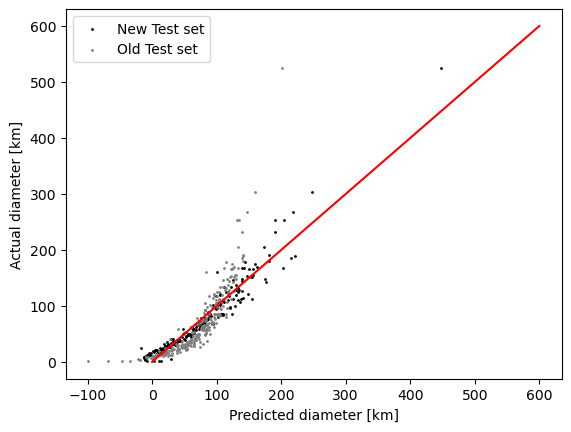

In [8]:
### EXAMPLE SOLUTIONS ###
# Compare your new results to your old results

print("\nTesting model...")
# Test your model with your test set
predict_test2 = model2.predict(feat_test2)

# also curious to see what happens if we feed in the training set. Want to check for over-fitting
predict_train2 = model2.predict(feat_train2) 

        
print("Results:")
# Comparing predictions to "truth" values
plt.scatter(predict_test2, label_test2.values.tolist(), s=1, color="black", label="New Test set")
plt.scatter(predict_test, label_test.values.tolist(), s=1, color="grey", label="Old Test set")
plt.plot(np.linspace(0,600), np.linspace(0,600), color="red") # one-to-one line
plt.xlabel("Predicted diameter [km]")
plt.ylabel("Actual diameter [km]")
plt.legend()
plt.show()

## (OPTIONAL) Testing on larger dataset
A more recent asteroid dataset has been compiled here: https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset/data

Does using this dataset, which may contain valid data for a larger sample of asteroids, improve your model? 

*NOTE: this dataset does not include all of the same headers as the original, so certain ML models may not perform well, depending on how you chose to build your model. Does using only the features in this larger dataset result in a more accurate model?*


In [ ]:
# Your code here

## Polynomial Regression 

You may notice that performing exponential operations on certain features result in better models than keeping all features in their linear state. This may hint towards the fact that an accurate model may not be linear at all. Can you model be improved by deviating from linear regression models? 

We can explore polynomial regression using `sklearn.preprocessing.PolynomialFeatures()` (for example, [as shown by this tutorial](https://www.kaggle.com/code/mahamedmahmoud/using-regression-diameter-classification-pha)). 

### Objective: 
*Transform your model into a polynomial and determine whether it returns a better fit than linear regression. What polynomial degree returns the best fit? How does it compare to your previous model(s)?*

*SUGGESTION: You may wish to experiment with tools such as `sklearn.model_selection.GridSearchCV` to optimize your polynomial.*

Polynomial Regression Results:
Train MAE: 8.2141
Test MAE: 8.6122
Train MSE: 178.4217
Test MSE: 153.9532
Train R²: 0.9568
Test R²: 0.9606


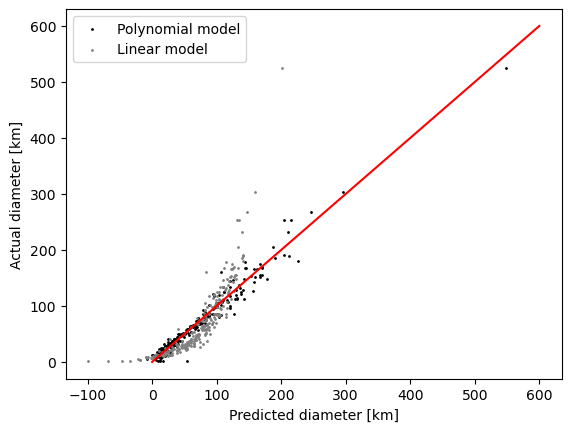

In [10]:
### EXAMPLE SOLUTIONS ###

# Create polynomial features
poly = PolynomialFeatures(degree=3)
feat_train_poly = poly.fit_transform(feat_train)
feat_test_poly = poly.fit_transform(feat_test)

# Initialize and train the model
poly_model = LinearRegression()
poly_model.fit(feat_train_poly, label_train)

# Predict on train and test sets
label_train_pred_poly = poly_model.predict(feat_train_poly)
label_test_pred_poly = poly_model.predict(feat_test_poly)

# Calculate metrics
train_mae_poly = mean_absolute_error(label_train, label_train_pred_poly)
train_mse_poly = mean_squared_error(label_train, label_train_pred_poly)
train_r2_poly = r2_score(label_train, label_train_pred_poly)

test_mae_poly = mean_absolute_error(label_test, label_test_pred_poly)
test_mse_poly = mean_squared_error(label_test, label_test_pred_poly)
test_r2_poly = r2_score(label_test, label_test_pred_poly)

# Print results
print("Polynomial Regression Results:")
print(f"Train MAE: {train_mae_poly:.4f}")
print(f"Test MAE: {test_mae_poly:.4f}")
print(f"Train MSE: {train_mse_poly:.4f}")
print(f"Test MSE: {test_mse_poly:.4f}")
print(f"Train R²: {train_r2_poly:.4f}")
print(f"Test R²: {test_r2_poly:.4f}")

plt.scatter(label_test_pred_poly, label_test.values.tolist(), s=1, color="black", label="Polynomial model")
plt.scatter(predict_test, label_test.values.tolist(), s=1, color="gray", label="Linear model")
plt.plot(np.linspace(0,600), np.linspace(0,600), color="red") # one-to-one line
plt.xlabel("Predicted diameter [km]")
plt.ylabel("Actual diameter [km]")
plt.legend()
plt.show()

## Applying the ML model to virtual asteroids from a published model
We made some good progress building linear and polynomial regression models using the dataset provided, but you may have noticed that your cleaned dataset is much, much shorter than the full asteroid dataset. Unfortunately, a lack of good data may limit the effectiveness of any model you hope to develop and your ability to test it. One way around a lack of observational data for testing models is to generate a simulated dataset using theoretical models (though, note, this may introduce unintended biases into the model). Here we will generate a simulated population of asteroids. We will use this new set to determine whether your ML model can accurately recover the diameters of the input asteroids.

Our virtual asteroids will be generated based on the results of a recent paper, which approximated a relationship between diameter (in km), albedo (p), and absolute magnitude parameter (H): 

$D = \frac{1329}{\sqrt{p}}10^{-0.2H}$ 

[(Petrov 2025, Res. Notes AAS 9, 233)](https://iopscience.iop.org/article/10.3847/2515-5172/ae01a5/ampdf)


Before we use this to generate simulated asteroids, it's a good idea to double-check this researcher's work and inspect how well the model above represents the asteroids in the JPL dataset.

### Objective:
*Create a function that returns the diameter of an asteroid based on the equation above. Using that function, make a few plots that demonstrate how close/far the model is from the data results. Where does this published model perform best, and where does it struggle?*

*Are you satisfied with the results of the paper cited above? If not, is there anything you can do to improve it?*

In [11]:
### EXAMPLE SOLUTIONS ###
# Write a function based on the equation above that will return 
# a diameter given an albedo and H value. 

def diameter(p, H): 
    """
    Returns a diameter or array of diameters of an asteroid given a measured 
    albedo and Absolute magnitude parameter. 
    
    PARAMETERS
    -----------
    p (float or array): Asteroid albedo 
    H (float or array): Absolute magnitude parameter
    
    RETURNS
    -----------
    D (float or array): Estimated asteroid diameter (units km)
    """
    
    ### INPUT NEEDED ###
    D = (1329/np.sqrt(p))*10**(-0.2*H)
    return D

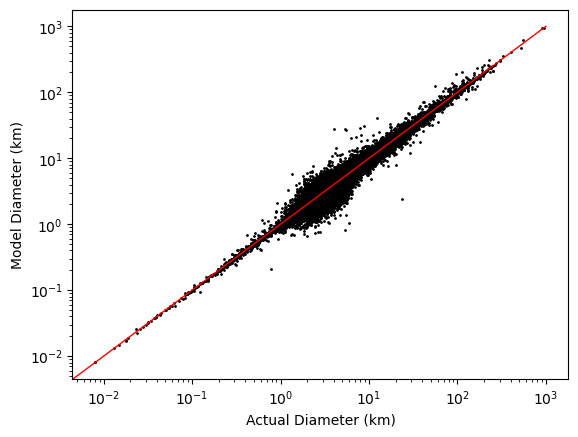

In [12]:
### EXAMPLE SOLUTIONS ###
### Make plots to demonstrate goodness of fit ###

# Reading in asteroid data from DataFrame
Hs = np.array(asteroids["H"].values)
Ds = np.array([np.float64(a) for a in asteroids["diameter"].values.tolist()])
albedos = np.array(asteroids["albedo"].values)

# Feeding parameters into diameter model
model_D = diameter(albedos, Hs)

# Plotting model vs. actual diameter as scatterplot
plt.scatter(Ds, model_D, color="black", s=1)
plt.plot(np.linspace(0,1000), np.linspace(0,1000), color="red", lw=1)
plt.xlabel("Actual Diameter (km)")
plt.ylabel("Model Diameter (km)")
plt.xscale('log')
plt.yscale('log')

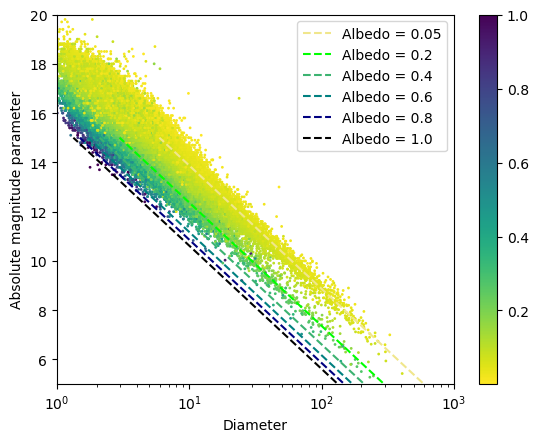

In [13]:
### EXAMPLE SOLUTIONS ###
plt.plot(diameter(np.array([0.05]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.05", c="khaki", ls="--")
plt.plot(diameter(np.array([0.2]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.2", c="lime", ls="--")
plt.plot(diameter(np.array([0.4]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.4", c="mediumseagreen", ls="--")
plt.plot(diameter(np.array([0.6]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.6", c="teal", ls="--")
plt.plot(diameter(np.array([0.8]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.8", c="navy", ls="--")
plt.plot(diameter(np.array([1.0]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 1.0", c="black", ls="--")
plt.scatter(Ds, Hs, s=1, c=albedos, cmap="viridis_r")
plt.legend()
plt.xlim(1,1e3)
plt.ylim(5,20)
plt.colorbar()
plt.xlabel("Diameter")
plt.ylabel("Absolute magnitude parameter")
plt.xscale("log")

*Notice, the known dataset is biased towards low albedo asteroids. How does this affect your model's ability to determine the diameters of high albedo asteroids?*

## Simulate an asteroid survey
Now that you have a working function for calculating asteroid diameters, you can use it randomly generate a large, simulated asteroid dataset. To do so, you will need to generate a set of albedos and absolute magnitude parameters, and then feed those values into your diameter function. You may also need to randomly generate values for other features you may have used in your own models, but it's worth noting that these values do not appear in the diameter calculations used by the theoretical model.

### Objective: 
*Simulate a dataset. For an added challenge, you may also add some simulated noise to the albedo and absolute magnitude parameter measurements to make the dataset more realistic. If your ML model uses features besides `p` and `H`, find a way to randomly generate reasonable values for those features for each simulated asteroid and add them to your virtual dataset.*

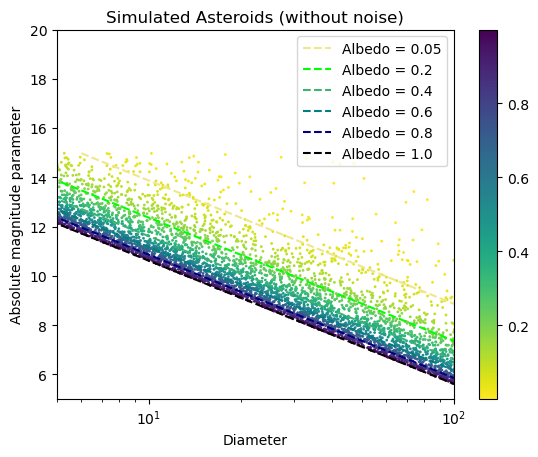

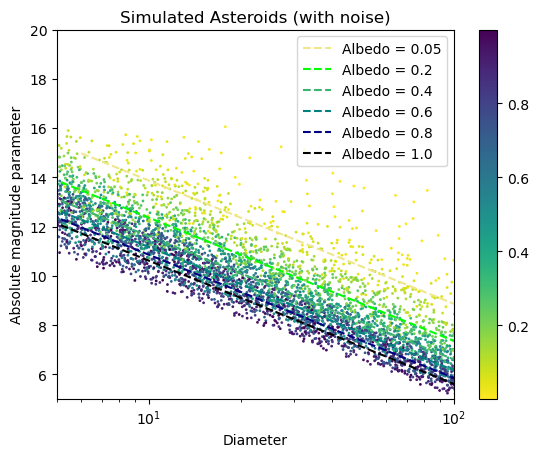

In [14]:
### EXAMPLE SOLUTIONS ###
rand_H = np.random.uniform(0.2,15,10000)
rand_alb = np.random.uniform(0,1,10000)
rand_D = diameter(rand_alb, rand_H)
rand_UB = np.random.uniform(np.nanmin(asteroids["UB"]),np.nanmax(asteroids["UB"]),10000)
rand_BV = np.random.uniform(np.nanmin(asteroids["BV"]),np.nanmax(asteroids["BV"]),10000)

# Adding random noise to the H and albedo measurements
# Max noise set to 10% 
rand_H_err = np.array([np.random.uniform(-h*.1,h*.1) for h in rand_H])
rand_alb_err = np.array([np.random.uniform(-a*.1,a*.1) for a in rand_alb])

rand_H_noisy = rand_H + rand_H_err
rand_alb_noisy = rand_alb + rand_alb_err

# Plotting random simulated asteroids against the model lines
# (should reproduce the model exact)
plt.plot(diameter(np.array([0.05]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.05", c="khaki", ls="--")
plt.plot(diameter(np.array([0.2]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.2", c="lime", ls="--")
plt.plot(diameter(np.array([0.4]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.4", c="mediumseagreen", ls="--")
plt.plot(diameter(np.array([0.6]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.6", c="teal", ls="--")
plt.plot(diameter(np.array([0.8]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.8", c="navy", ls="--")
plt.plot(diameter(np.array([1.0]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 1.0", c="black", ls="--")
plt.scatter(rand_D, rand_H, s=1, c=rand_alb, cmap="viridis_r")
plt.legend()
plt.xlim(5,100)
plt.ylim(5,20)
plt.colorbar()
plt.xlabel("Diameter")
plt.ylabel("Absolute magnitude parameter")
plt.title("Simulated Asteroids (without noise)")
plt.xscale("log")
plt.show()

# Plotting the "noisy" data (10% noise)
plt.plot(diameter(np.array([0.05]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.05", c="khaki", ls="--")
plt.plot(diameter(np.array([0.2]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.2", c="lime", ls="--")
plt.plot(diameter(np.array([0.4]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.4", c="mediumseagreen", ls="--")
plt.plot(diameter(np.array([0.6]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.6", c="teal", ls="--")
plt.plot(diameter(np.array([0.8]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 0.8", c="navy", ls="--")
plt.plot(diameter(np.array([1.0]*100), np.linspace(0,15,100)), np.linspace(0,15,100), 
         label="Albedo = 1.0", c="black", ls="--")
plt.scatter(rand_D, rand_H_noisy, s=1, c=rand_alb, cmap="viridis_r")
plt.legend()
plt.xlim(5,100)
plt.ylim(5,20)
plt.colorbar()
plt.xlabel("Diameter")
plt.ylabel("Absolute magnitude parameter")
plt.title("Simulated Asteroids (with noise)")
plt.xscale("log")
plt.show()

## Test your model on the simulated survey

### Objective: 
*Run the simulated asteroid dataset through your ML model to determine how well it predicts asteroid diameter. You may use any (or all) versions of your model that you've developed throughout this workshop. Which version works best? What conclusions can you make about your model compared to the theoretical model?*

*NOTE: The order in which your features were read into the model while training is the order in which they must be fed into the model for predictions. Otherwise, you'll encounter an error.*

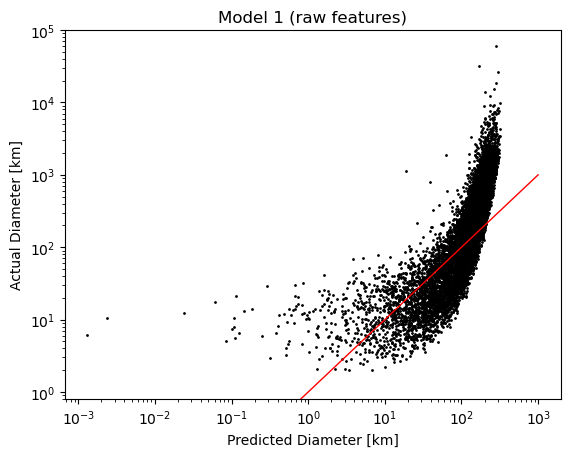

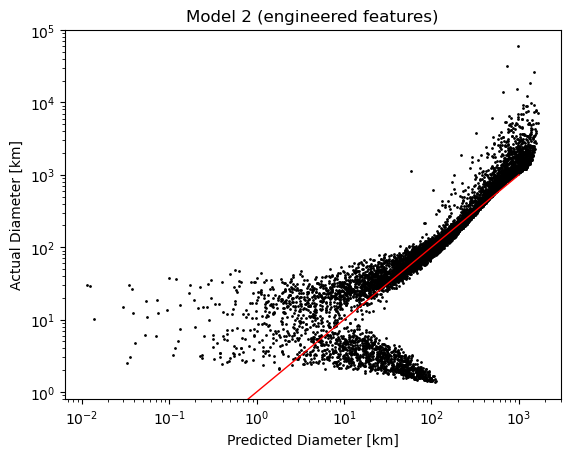

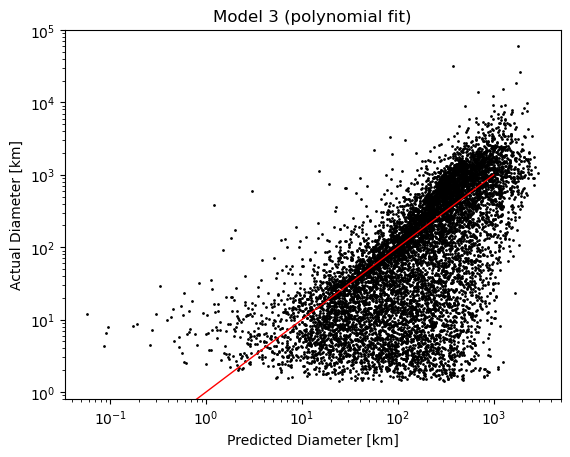

In [15]:
### EXAMPLE SOLUTIONS ###
# Run simulated data through ML model

sim_vals = [[rand_H[i], rand_alb[i], rand_D[i], rand_UB[i], rand_BV[i]] for i in range(10000)]

# Building DataFrame for model 1
sim_asteroids = pd.DataFrame(data=sim_vals, columns=["H", "albedo", "diameter", "UB", "BV"])
sim_feats = sim_asteroids[["albedo", "H", "BV", "UB"]]
sim_labels = sim_asteroids[["diameter"]].values.tolist()
predict_sim_1 = model.predict(sim_feats)

# Building features and DataFrame for model 2
sim_asteroids2 = sim_asteroids.copy()
sim_asteroids2["UV"] = sim_asteroids2["UB"] + sim_asteroids2["BV"]
sim_asteroids2["sqrt_H"] = np.sqrt(np.array(sim_asteroids2["H"]))
sim_asteroids2["sqrt_albedo"] = np.sqrt(np.array(sim_asteroids2["albedo"]))
sim_asteroids2["H_albedo"] = np.array(sim_asteroids2["H"])*np.array(sim_asteroids2["albedo"])
sim_feats2 = sim_asteroids2[feat_list2]

# Running model 2 on simulated data
predict_sim_2 = model2.predict(sim_feats2)

# Running model 3 on simulated data
sim_feats_poly = poly.fit_transform(sim_feats)
predict_sim_3 = poly_model.predict(sim_feats_poly)

# Plotting model vs. actual diameter as scatterplot
plt.title("Model 1 (raw features)")
plt.scatter(predict_sim_1, sim_labels, color="black", s=1)
plt.plot(np.linspace(0,1000), np.linspace(0,1000), color="red", lw=1)
plt.xlabel("Predicted Diameter [km]")
plt.ylabel("Actual Diameter [km]")
plt.xscale('log')
plt.yscale('log')
plt.show()

plt.title("Model 2 (engineered features)")
plt.scatter(predict_sim_2, sim_labels, color="black", s=1)
plt.plot(np.linspace(0,1000), np.linspace(0,1000), color="red", lw=1)
plt.xlabel("Predicted Diameter [km]")
plt.ylabel("Actual Diameter [km]")
plt.xscale('log')
plt.yscale('log')
plt.show()

plt.title("Model 3 (polynomial fit)")
plt.scatter(predict_sim_3, sim_labels, color="black", s=1)
plt.plot(np.linspace(0,1000), np.linspace(0,1000), color="red", lw=1)
plt.xlabel("Predicted Diameter [km]")
plt.ylabel("Actual Diameter [km]")
plt.xscale('log')
plt.yscale('log')
plt.show()

# (OPTIONAL) Training a model on simulated data

While I personally wouldn't recommend training a ML model based on a theoretical model for real research purposes, attempting to do so as an experiment can be a useful exercise. Since you know what your model SHOULD look like, inspecting the results of your ML model can help you understand some of the processes happening within the ML black box. 

### Objective: 
*Train a new ML model on your simulated dataset. How well does the new model predict diameters now? How well does this new ML model predict the diameters of the real asteroid dataset? What changes would you need to make to your model-building process that gets you closer to the theoretical equation used to build your simulated set?*

In [ ]:
### Your code here ###
#
#